# Plot results

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

In [26]:
def plot_multiple_max_latency(input_files, output_image="./plot_comparison_max.png"):
    try:
        plt.figure(figsize=(12, 6))
        
        # Define a list of distinct colors for the maximum latency lines
        colors = ['red', 'darkorange', 'purple', 'green', 'dodgerblue', 'brown']
        
        for i, input_file in enumerate(input_files):
            # Use the filename (without extension) as the label
            base_name = os.path.basename(input_file)
            label_name = os.path.splitext(base_name)[0]
            
            # Dynamic file format handling
            if input_file.endswith('.csv'):
                data = np.loadtxt(input_file, delimiter=',', skiprows=1)
            else:
                data = np.loadtxt(input_file)
                
            if data.size == 0:
                print(f"Warning: {input_file} contains no valid data, skipping.")
                continue

            cycles = data[:, 0]
            latencies = data[:, 1]
            
            # Calculate the Cumulative Maximum (WCET Envelope)
            cumulative_max = np.maximum.accumulate(latencies)
            absolute_max = cumulative_max[-1]
            
            color = colors[i % len(colors)]
            
            # Plot ONLY the cumulative maximum line (no scatter points)
            plt.plot(cycles, cumulative_max, color=color, linewidth=2.0, 
                     label=f"{label_name} (Max: {int(absolute_max)} µs)")

        # Formatting
        # plt.title('Worst-Case Execution Time (WCET) Envelope Comparison', fontsize=12, fontweight='bold')
        plt.xlabel('Cycle Count', fontsize=10)
        plt.ylabel('Max Latency (microseconds)', fontsize=10)
        
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(loc='upper left', framealpha=0.9)
        
        plt.tight_layout()
        plt.savefig(output_image, dpi=300)
        print(f"Comparison max-latency plot successfully saved as {output_image}")
        plt.show()

    except Exception as e:
        print(f"Error generating the comparison plot: {e}")

Comparison max-latency plot successfully saved as ./plot_comparison_max.png


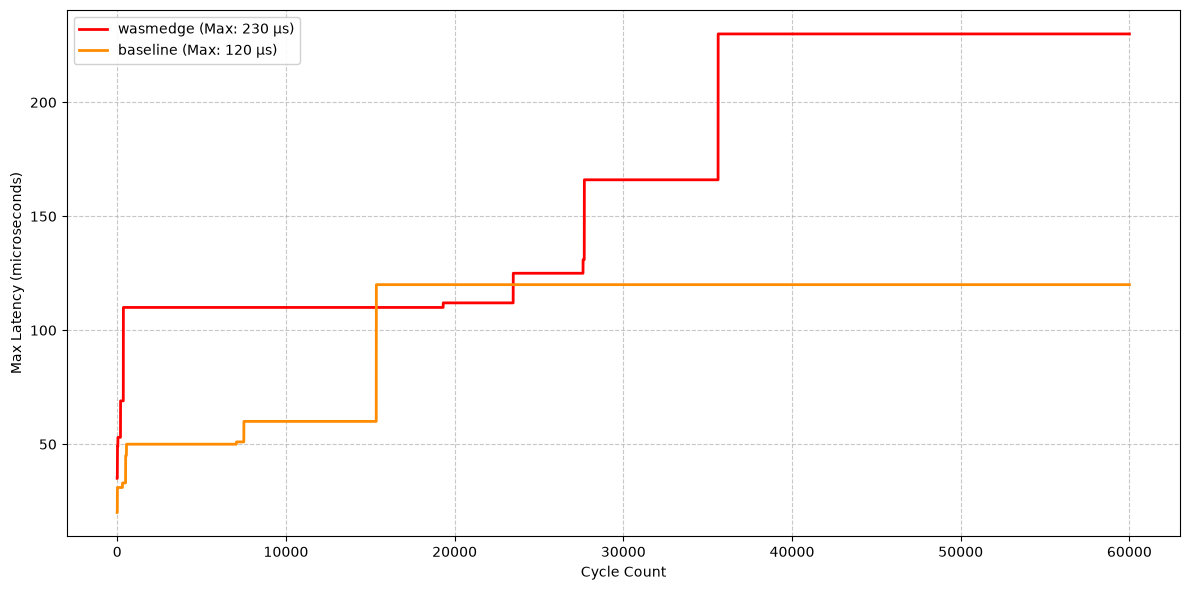

In [27]:
file_name = ["wasmedge", "baseline"]

plot_multiple_max_latency([f"./results/{name}.csv" for name in file_name])